In [86]:
import fastf1
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import os
import logging

logging.getLogger('fastf1').setLevel(logging.ERROR)
os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

all_results = []

for year in range(2018, 2025):
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    for _, event in schedule.iterrows():
        try:
            session = fastf1.get_session(year, event['RoundNumber'], 'R')
            session.load(telemetry=False, weather=False, messages=False)
            results = session.results[['Abbreviation', 'GridPosition', 'Position', 'Points', 'TeamName']].copy()
            results['Year'] = year
            results['Round'] = event['RoundNumber']
            all_results.append(results)
        except:
            pass


In [136]:
df = pd.concat(all_results, ignore_index=True)
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df = df.sort_values(['Year', 'Round']).reset_index(drop=True)

print(f"Skupaj vrstic: {len(df)}")
print(df.head())

Skupaj vrstic: 2979
  Abbreviation  GridPosition  Position  Points         TeamName  Year  Round
0          VET           3.0       1.0    25.0          Ferrari  2018      1
1          HAM           1.0       2.0    18.0         Mercedes  2018      1
2          RAI           2.0       3.0    15.0          Ferrari  2018      1
3          RIC           8.0       4.0    12.0  Red Bull Racing  2018      1
4          ALO          10.0       5.0    10.0          McLaren  2018      1


In [137]:
df['AvgPos_last5'] = df.groupby('Abbreviation')['Position'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['AvgGrid_last5'] = df.groupby('Abbreviation')['GridPosition'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['CumPoints'] = df.groupby(['Year', 'Abbreviation'])['Points'].transform(
    lambda x: x.shift(1).cumsum().fillna(0)
)

df_model = df.dropna(subset=['GridPosition', 'AvgPos_last5', 'AvgGrid_last5'])

features = ['GridPosition', 'AvgPos_last5', 'AvgGrid_last5', 'CumPoints']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(df_model[features], df_model['Position'])

print(df_model[features].head())

    GridPosition  AvgPos_last5  AvgGrid_last5  CumPoints
20           1.0           1.0            3.0       25.0
21           3.0           8.0           15.0        4.0
22           9.0           2.0            1.0       18.0
23           5.0          18.0           20.0        0.0
24           6.0          17.0            5.0        0.0


In [138]:
all_2025 = []

schedule_2025 = fastf1.get_event_schedule(2025, include_testing=False)
for _, event in schedule_2025[schedule_2025['RoundNumber'] <= 5].iterrows():
    try:
        session = fastf1.get_session(2025, event['RoundNumber'], 'R')
        session.load(telemetry=False, weather=False, messages=False)
        results = session.results[['Abbreviation', 'GridPosition', 'Position', 'Points', 'TeamName']].copy()
        results['Year'] = 2025
        results['Round'] = event['RoundNumber']
        all_2025.append(results)
    except:
        pass

df_2025 = pd.concat(all_2025, ignore_index=True)
df_2025['Position'] = pd.to_numeric(df_2025['Position'], errors='coerce')
df_2025['GridPosition'] = pd.to_numeric(df_2025['GridPosition'], errors='coerce')
df_2025 = df_2025.sort_values(['Year', 'Round']).reset_index(drop=True)

print(f"2025 vrstic: {len(df_2025)}")

2025 vrstic: 100


In [139]:
df_2025['AvgPos_last5'] = df_2025.groupby('Abbreviation')['Position'].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
df_2025['AvgGrid_last5'] = df_2025.groupby('Abbreviation')['GridPosition'].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
df_2025['CumPoints'] = df_2025.groupby('Abbreviation')['Points'].transform(
    lambda x: x.cumsum()
)

current_state = df_2025.groupby('Abbreviation').last().reset_index()
current_state = current_state[['Abbreviation', 'GridPosition', 'AvgPos_last5', 'AvgGrid_last5', 'CumPoints']]

print(current_state.sort_values('CumPoints', ascending=False).head(5))

   Abbreviation  GridPosition  AvgPos_last5  AvgGrid_last5  CumPoints
14          PIA           2.0           3.0            1.8       92.0
12          NOR          10.0           2.4            4.4       88.0
19          VER           1.0           3.0            3.2       81.0
15          RUS           3.0           3.6            3.4       68.0
11          LEC           4.0           7.4            4.6       43.0


In [140]:
points_system = {1:25, 2:18, 3:15, 4:12, 5:10, 6:8, 7:6, 8:4, 9:2, 10:1}

current_state = current_state.copy()
all_predictions = []

for round_num in range(6, 25):
    current_state['GridPosition'] = current_state['AvgGrid_last5'].apply(
        lambda x: max(1, min(20, int(np.random.normal(x, 2))))
    )
    
    current_state['PredictedPosition'] = model.predict(current_state[features])
    
    current_state = current_state.sort_values('PredictedPosition').reset_index(drop=True)
    current_state['FinalPosition'] = range(1, len(current_state) + 1)
    
    current_state['RoundPoints'] = current_state['FinalPosition'].map(points_system).fillna(0)
    
    round_pred = current_state[['Abbreviation', 'FinalPosition', 'RoundPoints']].copy()
    round_pred['Round'] = round_num
    all_predictions.append(round_pred)
    
    current_state['AvgPos_last5'] = (current_state['AvgPos_last5'] * 4 + current_state['FinalPosition']) / 5
    current_state['AvgGrid_last5'] = (current_state['AvgGrid_last5'] * 4 + current_state['GridPosition']) / 5
    current_state['CumPoints'] = current_state['CumPoints'] + current_state['RoundPoints']

pred_df = pd.concat(all_predictions, ignore_index=True)

schedule_2025 = fastf1.get_event_schedule(2025, include_testing=False)
print("Napovedi po dirkah:\n")
for round_num, race in pred_df.groupby('Round'):
    top3 = race.sort_values('FinalPosition').head(3)['Abbreviation'].tolist()
    event_name = schedule_2025[schedule_2025['RoundNumber'] == round_num]['EventName'].iloc[0]
    print(f"Dirka {round_num} - {event_name}")
    print(f"  1. {top3[0]}  2. {top3[1]}  3. {top3[2]}\n")

points_first5 = df_2025.groupby('Abbreviation')['Points'].sum().reset_index()
points_predicted = pred_df.groupby('Abbreviation')['RoundPoints'].sum().reset_index()
total = points_first5.merge(points_predicted, on='Abbreviation')
total['TotalPoints'] = total['Points'] + total['RoundPoints']
total = total.sort_values('TotalPoints', ascending=False)

print("\nNapoved prvaka 2025:")
print(total[['Abbreviation', 'TotalPoints']].head(5))

Napovedi po dirkah:

Dirka 6 - Miami Grand Prix
  1. VER  2. NOR  3. RUS

Dirka 7 - Emilia Romagna Grand Prix
  1. PIA  2. LEC  3. NOR

Dirka 8 - Monaco Grand Prix
  1. VER  2. PIA  3. LEC

Dirka 9 - Spanish Grand Prix
  1. VER  2. LEC  3. PIA

Dirka 10 - Canadian Grand Prix
  1. NOR  2. PIA  3. ANT

Dirka 11 - Austrian Grand Prix
  1. NOR  2. VER  3. LEC

Dirka 12 - British Grand Prix
  1. PIA  2. VER  3. LEC

Dirka 13 - Belgian Grand Prix
  1. NOR  2. RUS  3. VER

Dirka 14 - Hungarian Grand Prix
  1. PIA  2. HAM  3. LEC

Dirka 15 - Dutch Grand Prix
  1. VER  2. PIA  3. NOR

Dirka 16 - Italian Grand Prix
  1. VER  2. PIA  3. NOR

Dirka 17 - Azerbaijan Grand Prix
  1. PIA  2. VER  3. NOR

Dirka 18 - Singapore Grand Prix
  1. PIA  2. VER  3. NOR

Dirka 19 - United States Grand Prix
  1. VER  2. PIA  3. NOR

Dirka 20 - Mexico City Grand Prix
  1. VER  2. PIA  3. LEC

Dirka 21 - São Paulo Grand Prix
  1. LEC  2. VER  3. PIA

Dirka 22 - Las Vegas Grand Prix
  1. VER  2. NOR  3. PIA

Dirka 

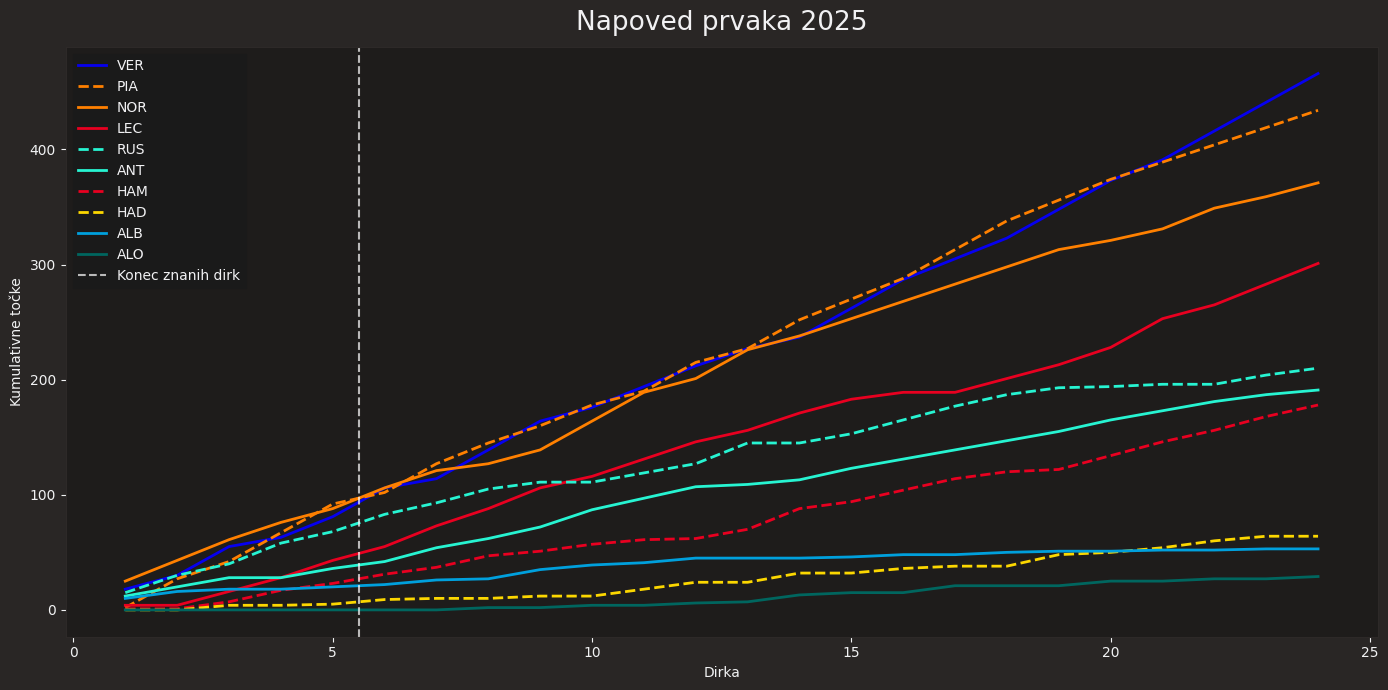

In [141]:
import matplotlib.pyplot as plt
import fastf1.plotting
fastf1.plotting.setup_mpl(color_scheme='fastf1')

top10_drivers = total.head(10)['Abbreviation'].tolist()

first10_by_round = df_2025.groupby(['Abbreviation', 'Round'])['Points'].sum().reset_index()
first10_by_round = first10_by_round[first10_by_round['Abbreviation'].isin(top10_drivers)]

pred_by_round = pred_df[pred_df['Abbreviation'].isin(top10_drivers)][['Abbreviation', 'Round', 'RoundPoints']].copy()
pred_by_round = pred_by_round.rename(columns={'RoundPoints': 'Points'})

all_rounds = pd.concat([first10_by_round, pred_by_round], ignore_index=True)
all_rounds = all_rounds.sort_values(['Abbreviation', 'Round'])
all_rounds['CumPoints'] = all_rounds.groupby('Abbreviation')['Points'].cumsum()

fig, ax = plt.subplots(figsize=(14, 7))

for driver in top10_drivers:
    driver_data = all_rounds[all_rounds['Abbreviation'] == driver]
    try:
        style = fastf1.plotting.get_driver_style(driver, ['color', 'linestyle'], session)
        ax.plot(driver_data['Round'], driver_data['CumPoints'],
                label=driver, color=style['color'], linestyle=style.get('linestyle', '-'), linewidth=2)
    except:
        ax.plot(driver_data['Round'], driver_data['CumPoints'], label=driver, linewidth=2)

ax.axvline(x=5.5, color='white', linestyle='--', alpha=0.7, label='Konec znanih dirk')
ax.set_xlabel('Dirka')
ax.set_ylabel('Kumulativne točke')
ax.set_title('Napoved prvaka 2025')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [142]:
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances)

         Feature  Importance
0   GridPosition    0.403551
2  AvgGrid_last5    0.208656
3      CumPoints    0.199929
1   AvgPos_last5    0.187864
